This script changes the modelling goal from predicting price direction to predicting future volatility, which is how much prices are expected to fluctuate over a period of time. In quantitative finance, volatility is often more predictable than direction, and it plays a central role in risk management, option pricing, and portfolio construction.

The script uses historical OHLCV data (Open, High, Low, Close, Volume) to estimate forward 10-day realized volatility, showing that market data must be used carefully and with the right target to extract meaningful signals.

In [75]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Tuple, Optional, Dict

import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


## Configuration
The configuration block defines all important settings in one place so the experiment is easy to understand and modify. A ticker limit is used to control runtime by restricting how many stocks are loaded, while still guaranteeing that a small set of “focus tickers” is always included for visualization. The volatility horizon specifies how far into the future volatility is predicted. In this case, the model learns to predict volatility over the next 10 trading days. Sequence length controls how much historical information the LSTM sees at once. Training parameters such as batch size, learning rate, number of epochs, and early stopping patience define how the neural network is trained.

Random seeds are fixed to ensure results are reproducible. 

In [76]:
DATA_DIR = "../data/raw/Stocks"

TICKER_LIMIT = 200
FOCUS_TICKERS = ["amzn", "msft", "tsco"]

TRAIN_FRAC = 0.85
LSTM_VAL_FROM_TRAIN = 0.15

VOLATILITY_HORIZON = 10

SEQ_LEN = 40
BATCH_SIZE = 64
LSTM_LR = 3e-4
LSTM_EPOCHS = 40
LSTM_PATIENCE = 6

LOG_CLIP_QUANTILES = (1, 99)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)


##  Garman–Klass realized variance
Instead of relying only on closing prices, the Garman–Klass formula uses the daily high, low, open, and close prices to estimate how volatile the stock was during the day. This estimator is widely used in finance because it extracts more information from the trading range and is more statistically efficient than simple close-to-close returns. This daily variance becomes the fundamental building block for both features and targets later in the pipeline. Traditional volatility only looks at closing prices, missing
important information about how much the price moved during the day. The Garman-Klass estimator is more accurate because it captures intraday price swings.

In [77]:
def compute_garman_klass(df: pd.DataFrame) -> pd.Series:
    log_hl = np.log(df["High"] / df["Low"])
    log_co = np.log(df["Close"] / df["Open"])
    gk_var = 0.5 * (log_hl ** 2) - (2 * np.log(2) - 1) * (log_co ** 2)
    return gk_var

## Feature Engineering Functions
Multiple features are created to capture different aspects of volatility patterns including: short-term vs long term volatility; sudden changes in volatility; whether we're in a calm or turbulent market period

In [78]:
def compute_realized_volatility(returns: pd.Series, window: int) -> pd.Series:
    return returns.rolling(window).std()


def compute_exponential_volatility(returns: pd.Series, span: int) -> pd.Series:
    return returns.ewm(span=span).std()


def compute_volatility_regime(volatility: pd.Series, window: int = 60) -> pd.Series:
    rolling_quantiles = volatility.rolling(window, min_periods=20)
    q33 = rolling_quantiles.quantile(0.33)
    q66 = rolling_quantiles.quantile(0.66)

    regime = pd.Series(1, index=volatility.index)  # medium
    regime[volatility < q33] = 0                    # low
    regime[volatility > q66] = 2                    # high
    return regime


def compute_volatility_features_v2(df: pd.DataFrame) -> pd.DataFrame:
    returns = df['Close'].pct_change()
    features = {}

    # Basic realized & exponential volatility at different time scales
    for window in [5, 10, 20]:
        features[f'rv_{window}d'] = compute_realized_volatility(returns, window)
        features[f'ev_{window}d'] = compute_exponential_volatility(returns, window)

    # Volatility changes
    features['vol_change_5d'] = features['rv_5d'].pct_change(5)
    features['vol_change_10d'] = features['rv_10d'].pct_change(10)

    # Volatility regimes (calm, normal, or turbulent market?)
    features['vol_regime'] = compute_volatility_regime(features['rv_20d'])
    features['vol_regime_low'] = (features['vol_regime'] == 0).astype(int)
    features['vol_regime_high'] = (features['vol_regime'] == 2).astype(int)

    # 4. Relative volatility (is current volatility high or low compared to recent history?)
    ma_60 = features['rv_20d'].rolling(60).mean()
    features['vol_zscore'] = (features['rv_20d'] - ma_60) / (
        features['rv_20d'].rolling(60).std() + 1e-9
    )

    # Volatility ratios (comparing short-term to long-term)
    features['vol_ratio_5_20'] = features['rv_5d'] / (features['rv_20d'] + 1e-9)

    # Price range features (how wide is the daily trading range?)
    features['high_low_pct'] = (df['High'] - df['Low']) / df['Close']
    features['range_ma5'] = features['high_low_pct'].rolling(5).mean()
    features['range_ma10'] = features['high_low_pct'].rolling(10).mean()

    # Return-based features (absolute returns and squared returns)
    for window in [5, 10, 20]:
        features[f'abs_return_ma{window}'] = returns.abs().rolling(window).mean()
        features[f'squared_return_ma{window}'] = (returns ** 2).rolling(window).mean()

    # Return autocorrelation (do today's returns predict tomorrow's?)
    features['return_autocorr_5'] = returns.rolling(20).apply(
        lambda x: x.autocorr(lag=5) if len(x) > 5 else 0, raw=False
    )

    # Volume volatility (is trading volume stable or erratic?)
    volume_pct = df['Volume'].pct_change()
    features['volume_vol_5d'] = volume_pct.rolling(5).std()
    features['volume_vol_10d'] = volume_pct.rolling(10).std()

    # Extreme returns (how often do we see unusually large moves?)
    features['extreme_returns_5d'] = (
        returns.abs() > returns.rolling(60).quantile(0.95)
    ).rolling(5).sum()

    # Overnight gaps (difference between today's open and yesterday's close)
    features['gap'] = (df['Open'] - df['Close'].shift()) / df['Close'].shift()
    features['gap_vol_5d'] = features['gap'].rolling(5).std()

    return pd.DataFrame(features, index=df.index)

## Single Ticker Processing
Reads stock price data files and prepares them for analysis. The data is loaded and cleaned by sorting by date and handling missing values. The volatility features are calculated, prediction targets are created (which is the volatility over the next 10 days). The data is then combined from many different stocks into one large dataset.

In [79]:
def process_single_ticker(path: Path, min_rows_after: int = 250) -> Optional[pd.DataFrame]:
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"Skipping {path.name}: read error {e}")
        return None

    required_cols = {"Date", "Open", "High", "Low", "Close", "Volume"}
    if not required_cols.issubset(df.columns):
        print(f"Skipping {path.name}: missing OHLCV columns")
        return None

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date","Open","High","Low","Close","Volume"])
    df = df.sort_values("Date").reset_index(drop=True)

    if len(df) < 300:
        return None

    ticker = path.stem.split('.')[0]
    df["Ticker"] = ticker

    df["GK_var"] = compute_garman_klass(df)

    # HAR features: daily, weekly, monthly realized variance
    df["GK_RV_d"] = df["GK_var"].rolling(1).sum().shift(1)    # yesterday
    df["GK_RV_w"] = df["GK_var"].rolling(5).sum().shift(1)    # last week
    df["GK_RV_m"] = df["GK_var"].rolling(22).sum().shift(1)   # last month

    # Log transform (volatility is log-normal distributed)
    df["log_GK_RV_d"] = np.log(df["GK_RV_d"] + 1e-9)
    df["log_GK_RV_w"] = np.log(df["GK_RV_w"] + 1e-9)
    df["log_GK_RV_m"] = np.log(df["GK_RV_m"] + 1e-9)

    vol_features = compute_volatility_features_v2(df)
    df = pd.concat([df, vol_features], axis=1)

    df["target_volatility"] = (
        df["GK_var"].rolling(VOLATILITY_HORIZON).sum().shift(-VOLATILITY_HORIZON)
    )

    df = df.dropna(subset=["target_volatility"])
    if len(df) < min_rows_after:
        return None

    df["target_log_vol"] = np.log(df["target_volatility"] + 1e-9)

    return df


def load_all_tickers_for_volatility(
    data_dir: str,
    ticker_limit: Optional[int] = None,
    min_rows_after: int = 250
) -> Tuple[pd.DataFrame, List[str]]:
    data_path = Path(data_dir)
    files = sorted(data_path.glob("*.txt"))

    ticker_to_file = {}
    for path in files:
        ticker = path.stem.split('.')[0]
        ticker_to_file[ticker] = path

    selected_paths: List[Path] = []
    focus_set = set(FOCUS_TICKERS)

    for tk in focus_set:
        if tk in ticker_to_file:
            selected_paths.append(ticker_to_file[tk])
        else:
            print(f"focus ticker {tk} not found in files")

    if ticker_limit is None:
        for path in files:
            if path not in selected_paths:
                selected_paths.append(path)
    else:
        for path in files:
            if len(selected_paths) >= ticker_limit:
                break
            if path not in selected_paths:
                selected_paths.append(path)

    dfs = []
    for path in selected_paths:
        df_t = process_single_ticker(path, min_rows_after=min_rows_after)
        if df_t is not None:
            dfs.append(df_t)

    if not dfs:
        raise RuntimeError("No valid tickers found after processing.")

    df_all = pd.concat(dfs, ignore_index=True)

    exclude_cols = [
        'Date', 'Open', 'High', 'Low', 'Close', 'Volume',
        'target_volatility', 'target_log_vol', 'GK_var', 'Ticker'
    ]
    feature_cols = [c for c in df_all.columns if c not in exclude_cols]

    # Clean up missing values
    df_all[feature_cols] = df_all[feature_cols].ffill().bfill()
    df_all = df_all.replace([np.inf, -np.inf], np.nan)
    df_all[feature_cols] = df_all[feature_cols].ffill().bfill()
    df_all = df_all.dropna(subset=feature_cols + ["target_log_vol"])

    df_all["TickerId"] = df_all["Ticker"].astype("category").cat.codes

    return df_all.reset_index(drop=True), feature_cols

## LSTM Neural Network Architecture
A Long Short-Term Memory (LSTM) is a type of neural network that is good at learning patterns in sequation data. LSTMs can remember important pattern from the past such and complex, non-linear relationships. They are especially good for teim series data where order matters. In this implementation, we use "ticker embeddings" which allows the model to learn unique characteristics of each stock while still sharing knowldge across all stocks.

In [80]:
class PooledLSTMVolatility(nn.Module):
    def __init__(self, n_features: int, n_tickers: int, emb_dim: int = 8,
                 hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.25):
        super().__init__()

        # Ticker embedding: each stock gets a learnable vector
        self.ticker_emb = nn.Embedding(n_tickers, emb_dim)

        # bidirectional=False means it only looks backward in time (no future peeking!)
        self.lstm = nn.LSTM(
            n_features + emb_dim,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False,
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),       # prevents overfitting
            nn.Linear(32, 1)           # final prediction
        )

    def forward(self, x, ticker_ids):
        # Get ticker embedding and expand to match sequence length
        emb = self.ticker_emb(ticker_ids)
        emb_exp = emb.unsqueeze(1).expand(-1, x.size(1), -1)

        x_cat = torch.cat([x, emb_exp], dim=-1)

        _, (hidden, _) = self.lstm(x_cat)
        hidden = hidden[-1]

        output = self.fc(hidden).squeeze(1)
        return output


class PooledSeqDataset(Dataset):
    def __init__(self, X, y, ticker_ids):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
        self.ticker_ids = torch.from_numpy(ticker_ids).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.ticker_ids[idx]


## Sequence Building for LSTM
This section converts the tabular data into seauences that the LSTM can learn from. The LSTM needs to see windows of historical data to make predictions. For example, to predict tomorrow's volatility, we may show it the last 40 days of eatures. We keep each stocks's data separate. Sequences never mix data from different stocks

In [81]:
def build_sequences_pooled(
    df: pd.DataFrame,
    feature_cols: List[str],
    seq_len: int,
    return_meta: bool = False
):
    X_list, y_list, tid_list = [], [], []
    meta = []

    # Process each stock separately
    for ticker, g in df.groupby("Ticker"):
        g = g.sort_values("Date")  # ensure chronological order
        arr = g[feature_cols].to_numpy(dtype=np.float32)
        targets_log = g["target_log_vol"].to_numpy(dtype=np.float32)
        ticker_id = int(g["TickerId"].iloc[0])

        if len(g) < seq_len:
            continue  # skip if not enough history

        # Create sliding windows
        for i in range(seq_len - 1, len(g)):
            X_list.append(arr[i - seq_len + 1:i + 1])
            y_list.append(targets_log[i])
            tid_list.append(ticker_id)

            if return_meta:
                meta.append({
                    "Ticker": ticker,
                    "Date": g["Date"].iloc[i],
                    "target_log_vol": targets_log[i]
                })

    if not X_list:
        if return_meta:
            return (
                np.zeros((0, seq_len, len(feature_cols)), dtype=np.float32),
                np.zeros((0,), dtype=np.float32),
                np.zeros((0,), dtype=np.int64),
                pd.DataFrame(),
            )
        return (
            np.zeros((0, seq_len, len(feature_cols)), dtype=np.float32),
            np.zeros((0,), dtype=np.float32),
            np.zeros((0,), dtype=np.int64),
            None,
        )

    X = np.stack(X_list)
    y = np.array(y_list, dtype=np.float32)
    tids = np.array(tid_list, dtype=np.int64)

    if return_meta:
        meta_df = pd.DataFrame(meta)
        meta_df["target_real"] = np.exp(meta_df["target_log_vol"])
        return X, y, tids, meta_df

    return X, y, tids, None


## LSTM Training
The following function trains the LSTM to predict volatility. The Model is shown examples from the training data which the model makes predictions on. The predictions are compared to the actual values to calculate the loss. The model weihts are then adjusted to make better predictions. This process is then repeated thousands of times until the model improves. If the validation performance stops improving the training will stop early.

In [82]:
def train_pooled_lstm(
    X_train, y_train, tid_train,
    X_val, y_val, tid_val,
    n_features: int,
    n_tickers: int,
    ticker: str = "POOLED"
) -> PooledLSTMVolatility:

    # Use GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PooledLSTMVolatility(n_features, n_tickers).to(device)

    # Optimizer: adjusts model weights
    opt = torch.optim.AdamW(model.parameters(), lr=LSTM_LR, weight_decay=5e-4)

    #reduce learning rate when stuck
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', patience=3, factor=0.5
    )

    loss_fn = nn.MSELoss()

    train_loader = DataLoader(
        PooledSeqDataset(X_train, y_train, tid_train),
        batch_size=BATCH_SIZE,
        shuffle=True  # shuffle for better training
    )
    val_loader = DataLoader(
        PooledSeqDataset(X_val, y_val, tid_val),
        batch_size=BATCH_SIZE,
        shuffle=False  # no need to shuffle validation
    )

    # Early stopping variables
    best_state = None
    best_val_loss = float('inf')
    patience = 0

    # Training loop
    for epoch in range(1, LSTM_EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for xb, yb, tb in train_loader:
            xb, yb, tb = xb.to(device), yb.to(device), tb.to(device)

            opt.zero_grad()              # reset gradients
            pred = model(xb, tb)         # forward pass
            loss = loss_fn(pred, yb)     # calculate loss
            loss.backward()              # backpropagation

            # Gradient clipping prevents exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            opt.step()                   # update weights
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb, tb in val_loader:
                xb, yb, tb = xb.to(device), yb.to(device), tb.to(device)
                pred = model(xb, tb)
                loss = loss_fn(pred, yb)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        # Adjust learning rate if stuck
        scheduler.step(val_loss)

        if epoch == 1 or epoch % 10 == 0:
            print(f"[LSTM {ticker}] Epoch {epoch:02d} | train={train_loss:.6f} | val={val_loss:.6f}")

        # Early stopping logic
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= LSTM_PATIENCE:
                print(f"[LSTM {ticker}] Early stop at epoch {epoch}, best val MSE={best_val_loss:.6f}")
                break

    # Load best model
    if best_state is not None:
        model.load_state_dict(best_state)

    return model


## Evaluation Metrics
The models are ranked on 5 metrics:
- RMSE/MAE: Average prediction error (lower is better)
- R²: How much of the variation we explain (1.0 = perfect, 0 = useless)
- Correlation: How well predictions move with actual values
- Direction accuracy: Can we predict if volatility will be high or low?
- Quintile accuracy: Can we rank stocks by volatility correctly?

In [83]:
def compute_metrics(y_true_real, y_pred_real) -> Dict[str, float]:
    """
    Calculate comprehensive performance metrics.

    All metrics use real-scale volatility (not log-transformed) because
    that's what people actually care about in practice.
    """
    mse = mean_squared_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mse)  # Root Mean Squared Error
    mae = mean_absolute_error(y_true_real, y_pred_real)  # Mean Absolute Error
    r2 = r2_score(y_true_real, y_pred_real)  # R-squared

    # Correlation coefficient
    corr = np.corrcoef(y_true_real, y_pred_real)[0, 1] if len(y_true_real) > 1 else 0

    # Direction accuracy
    y_true_median = np.median(y_true_real)
    y_true_high = (y_true_real > y_true_median).astype(int)
    y_pred_high = (y_pred_real > y_true_median).astype(int)
    dir_acc = np.mean(y_true_high == y_pred_high)

    # Quintile accuracy
    try:
        y_true_quintiles = pd.qcut(y_true_real, q=5, labels=False, duplicates='drop')
        y_pred_quintiles = pd.qcut(y_pred_real, q=5, labels=False, duplicates='drop')
        quintile_acc = np.mean(np.abs(y_true_quintiles - y_pred_quintiles) <= 1)
    except ValueError:
        quintile_acc = np.nan

    return {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'corr': corr,
        'dir_acc': dir_acc,
        'quintile_acc': quintile_acc
    }


def plot_volatility_prediction(y_true, y_pred, ticker, horizon=10):
    shift = 10 # allign the predicted curve to the real one. Used 10 becase we have a 10 day horizon

    if shift > 0:
        pred_shifted = np.concatenate([y_pred[shift:], np.full(shift, np.nan)])
    else:
        pred_shifted = y_pred.copy()

    true_sm = pd.Series(y_true).rolling(5).mean()
    pred_sm = pd.Series(pred_shifted).rolling(5).mean()

    plt.figure(figsize=(12, 6))
    plt.plot(true_sm, label="Actual Volatility", color="black", linewidth=2.5)
    plt.plot(pred_sm, label="Predicted Volatility (shift-adjusted)",
             color="dodgerblue", linewidth=2)

    plt.title(f"{ticker}: Actual vs Predicted Volatility (Aligned for Horizon={horizon})",
              fontsize=16)
    plt.xlabel("Time (test period)")
    plt.ylabel("Volatility")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_actual_vs_pred_scatter(y_true, y_pred, ticker):

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.3, s=20, edgecolor="none")

    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2,
             label="Perfect prediction")

    plt.xlabel("Actual 10-day Volatility")
    plt.ylabel("Predicted 10-day Volatility")
    plt.title(f"{ticker}: Actual vs Predicted", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_abs_error_hist(y_true, y_pred, ticker):
    abs_err = np.abs(y_pred - y_true)
    plt.figure(figsize=(8, 5))
    plt.hist(abs_err, bins=40, alpha=0.8)
    plt.xlabel("|Prediction Error| (Volatility)")
    plt.ylabel("Frequency")
    plt.title(f"{ticker}: Distribution of Prediction Error", fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_direction_accuracy(dir_acc, ticker):
    plt.figure(figsize=(6, 5))
    plt.bar(["Random (50%)", f"{ticker} Model"], [0.50, dir_acc],
            color=["gray", "dodgerblue"])
    plt.ylim(0.45, 0.80)
    plt.ylabel("Accuracy")
    plt.title(f"{ticker}: Model Beats Random Guessing", fontsize=14)
    plt.tight_layout()
    plt.show()

## Load and Prepare Data
All stock data is loaded and processed, and then split into training and testing sets. We use chronological splitting as we are using time series data and the current values are dependednt on the values that came before it. The Training/Test split is 85%:15%. The training set is data that occurs earlier in time than the test set. This is crucial because we cannot train on future data and test on past data. In reality we only know the past when making rpedictions about the future.

In [84]:
print("=" * 80)
print(f"POOLED Volatility Prediction with Garman–Klass ({VOLATILITY_HORIZON}-day horizon)")
print("=" * 80)

df_all, feature_cols = load_all_tickers_for_volatility(DATA_DIR, TICKER_LIMIT)

print(f"  Total rows: {len(df_all):,}")
print(f"  Number of stocks: {df_all['Ticker'].nunique()}")
print(f"  Number of features: {len(feature_cols)}")
print(f"  Date range: {df_all['Date'].min()} to {df_all['Date'].max()}")

split_date = df_all["Date"].quantile(TRAIN_FRAC)
train_mask = df_all["Date"] <= split_date
test_mask = df_all["Date"] > split_date

df_train = df_all[train_mask].copy()
df_test = df_all[test_mask].copy()

print(f"✓ Data split complete!")
print(f"  Split date: {split_date}")
print(f"  Training rows: {len(df_train):,}")
print(f"  Test rows: {len(df_test):,}")
print(f"  Train/test ratio: {len(df_train)/len(df_all):.1%} / {len(df_test)/len(df_all):.1%}")

# Targets
y_train_log = df_train["target_log_vol"].values.astype(np.float32)
y_test_log = df_test["target_log_vol"].values.astype(np.float32)

# Convert from log scale to real scale
y_train_real = np.exp(y_train_log)
y_test_real = np.exp(y_test_log)

# Features
X_train = df_train[feature_cols].to_numpy(dtype=np.float32)
X_test = df_test[feature_cols].to_numpy(dtype=np.float32)

print(f"  Feature matrix shape: {X_train.shape}")
print(f"  Target shape: {y_train_log.shape}")

# scale features resistant to outliers
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nTraining volatility stats (real scale):")
print(f"  Mean: {y_train_real.mean():.6f}")
print(f"  Std: {y_train_real.std():.6f}")
print(f"  Min: {y_train_real.min():.6f}")
print(f"  Max: {y_train_real.max():.6f}")

print(f"\nTest volatility stats (real scale):")
print(f"  Mean: {y_test_real.mean():.6f}")
print(f"  Std: {y_test_real.std():.6f}")
print(f"  Min: {y_test_real.min():.6f}")
print(f"  Max: {y_test_real.max():.6f}")

# Compute log-volatility clipping range to prevent extreme predictions
clip_low, clip_high = np.percentile(y_train_log, LOG_CLIP_QUANTILES)
print(f"\nLog-vol clipping range (1st-99th percentile): [{clip_low:.3f}, {clip_high:.3f}]")

# Helper function to convert log predictions back to real scale with clipping
def exp_pred(log_arr: np.ndarray) -> np.ndarray:
    """Convert log-volatility to real volatility with safety clipping."""
    return np.exp(np.clip(log_arr, clip_low, clip_high))

# Calculate baseline (naive prediction: use historical average)
baseline_log = np.full_like(y_test_log, y_train_log.mean())
baseline_real = exp_pred(baseline_log)
baseline_r2 = r2_score(y_test_real, baseline_real)

print(f"  R² score: {baseline_r2:.4f}")

POOLED Volatility Prediction with Garman–Klass (10-day horizon)
Skipping accp.us.txt: read error No columns to parse from file
  Total rows: 490,395
  Number of stocks: 186
  Number of features: 35
  Date range: 1970-01-02 00:00:00 to 2017-10-27 00:00:00
✓ Data split complete!
  Split date: 2016-03-29 00:00:00
  Training rows: 416,965
  Test rows: 73,430
  Train/test ratio: 85.0% / 15.0%
  Feature matrix shape: (416965, 35)
  Target shape: (416965,)

Training volatility stats (real scale):
  Mean: 0.009494
  Std: 0.036234
  Min: 0.000000
  Max: 2.760086

Test volatility stats (real scale):
  Mean: 0.009423
  Std: 0.045501
  Min: 0.000000
  Max: 2.238755

Log-vol clipping range (1st-99th percentile): [-8.993, -2.303]
  R² score: -0.0174


## Training Ridge Regrssion Model
This section trains a Ridge regression model as a baseline model to compare to the LSTM. This modle is a linear model that predicts the target as a weighted sum of features. A ridge model is chosen over linear regression because the concept of regularisation is introduced whcih prevents overfitting when we have too many fetaures. The alpha parameter controls how much regularisation occurs.

In [85]:
print("\n" + "=" * 80)
print("TRAINING RIDGE REGRESSION")
print("=" * 80)

# Train Ridge model
ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train_log)

# Make predictions
ridge_pred_log = ridge.predict(X_test)
ridge_pred_real = exp_pred(ridge_pred_log)  # convert to real scale

# Evaluate performance
res_ridge = compute_metrics(y_test_real, ridge_pred_real)

print("\n" + "=" * 80)
print("RIDGE REGRESSION RESULTS")
print("=" * 80)
print(f"R² Score:           {res_ridge['r2']:.4f}")
print(f"Correlation:        {res_ridge['corr']:.4f}")
print(f"Direction Accuracy: {res_ridge['dir_acc']:.3f}")
print(f"Quintile Accuracy:  {res_ridge['quintile_acc']:.3f}")
print(f"RMSE:               {res_ridge['rmse']:.6f}")
print(f"MAE:                {res_ridge['mae']:.6f}")

results = {'Ridge': {"GLOBAL": res_ridge}, 'LSTM': {}}

df_test = df_test.copy()
df_test["ridge_pred_real"] = ridge_pred_real
df_test["target_real"] = y_test_real


TRAINING RIDGE REGRESSION

RIDGE REGRESSION RESULTS
R² Score:           0.1762
Correlation:        0.4827
Direction Accuracy: 0.871
Quintile Accuracy:  0.967
RMSE:               0.041299
MAE:                0.005615


/home/luka/Documents/git/stockprice_classifier/.venv/lib/python3.14/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.67469e-10): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


## Prepare Data for LST Training
The data is converted into sequences and a validation set is created specifically for LSTM training. A separate validation set is required because neural networks need careful monitoring during training to prevent overfitting. We use a training set for learning which consists of 70% of the original training data. A validation set is then used for monitoring and early stopping (15%). Then, for the final evaluation a test set is used which is kept completely separate so that the model has never seen this data beofre (15%)

In [86]:
train_dates = df_train["Date"]
val_start_date = train_dates.quantile(1 - LSTM_VAL_FROM_TRAIN)

df_train_lstm = df_train[df_train["Date"] < val_start_date].copy()
df_val_lstm = df_train[df_train["Date"] >= val_start_date].copy()
df_test_lstm = df_test.copy()

print(f"  LSTM Training rows:   {len(df_train_lstm):,}")
print(f"  LSTM Validation rows: {len(df_val_lstm):,}")
print(f"  LSTM Test rows:       {len(df_test_lstm):,}")
print(f"  Validation start: {val_start_date}")

# Get number of unique tickers for embedding layer
n_tickers = df_all["TickerId"].nunique()
print(f"\nNumber of unique stocks: {n_tickers}")

scaler_lstm = RobustScaler()
df_train_lstm[feature_cols] = scaler_lstm.fit_transform(df_train_lstm[feature_cols])
df_val_lstm[feature_cols] = scaler_lstm.transform(df_val_lstm[feature_cols])
df_test_lstm[feature_cols] = scaler_lstm.transform(df_test_lstm[feature_cols])


X_tr_seq, y_tr_seq_log, tid_tr, _ = build_sequences_pooled(
    df_train_lstm, feature_cols, SEQ_LEN, return_meta=False
)

X_val_seq, y_val_seq_log, tid_val, _ = build_sequences_pooled(
    df_val_lstm, feature_cols, SEQ_LEN, return_meta=False
)

X_te_seq, y_te_seq_log, tid_te, meta_test = build_sequences_pooled(
    df_test_lstm, feature_cols, SEQ_LEN, return_meta=True
)

print(f"\nSequence array shapes:")
print(f"  X_train: {X_tr_seq.shape}  (num_sequences, seq_length, num_features)")
print(f"  y_train: {y_tr_seq_log.shape}  (num_sequences,)")
print(f"  ticker_ids: {tid_tr.shape}  (num_sequences,)")

# Check if we have enough data for LSTM
if len(X_tr_seq) < 100 or len(X_te_seq) < 50:
    print("LSTM training will be skipped.")
    lstm_skip = True
else:
    lstm_skip = False


  LSTM Training rows:   354,355
  LSTM Validation rows: 62,610
  LSTM Test rows:       73,430
  Validation start: 2014-09-19 00:00:00

Number of unique stocks: 186

Sequence array shapes:
  X_train: (348504, 40, 35)  (num_sequences, seq_length, num_features)
  y_train: (348504,)  (num_sequences,)
  ticker_ids: (348504,)  (num_sequences,)


## Train LSTM
The training loss should decrease steadily. Validation losss should also decrease - if it increases, then we are overfitting. Early stopping prevents overfitting automatically.

In [87]:
if not lstm_skip:
    print("\n" + "=" * 80)
    print("TRAINING LSTM MODEL")
    print("=" * 80)

    if torch.cuda.is_available():
        print("GPU detected")
    else:
        print("No GPU detected")

    print(f"\nDataset sizes:")
    print(f"  • Training sequences:   {len(X_tr_seq):,}")
    print(f"  • Validation sequences: {len(X_val_seq):,}")
    print(f"  • Test sequences:       {len(X_te_seq):,}")

    # Train the model
    lstm_model = train_pooled_lstm(
        X_tr_seq, y_tr_seq_log, tid_tr,
        X_val_seq, y_val_seq_log, tid_val,
        n_features=len(feature_cols),
        n_tickers=n_tickers,
        ticker="POOLED"
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    lstm_model.eval()

    with torch.no_grad():
        X_te_t = torch.from_numpy(X_te_seq).float().to(device)
        tid_te_t = torch.from_numpy(tid_te).long().to(device)
        lstm_pred_log = lstm_model(X_te_t, tid_te_t).cpu().numpy()


    # Convert to real scale
    lstm_pred_real_global = exp_pred(lstm_pred_log)
    y_te_real_global = np.exp(y_te_seq_log)

    meta_test = meta_test.copy()
    meta_test["lstm_pred_real"] = lstm_pred_real_global

    res_lstm_global = compute_metrics(y_te_real_global, lstm_pred_real_global)
    results['LSTM']["GLOBAL"] = res_lstm_global

    print("\n" + "=" * 80)
    print("LSTM RESULTS")
    print("=" * 80)
    print(f"R² Score:           {res_lstm_global['r2']:.4f}")
    print(f"Correlation:        {res_lstm_global['corr']:.4f}")
    print(f"Direction Accuracy: {res_lstm_global['dir_acc']:.3f}")
    print(f"Quintile Accuracy:  {res_lstm_global['quintile_acc']:.3f}")
    print(f"RMSE:               {res_lstm_global['rmse']:.6f}")
    print(f"MAE:                {res_lstm_global['mae']:.6f}")

    print("\nComparison with Ridge:")
    print(f"R² improvement: {(res_lstm_global['r2'] - res_ridge['r2']):.4f}")
    print(f"Correlation improvement: {(res_lstm_global['corr'] - res_ridge['corr']):.4f}")

    if res_lstm_global['r2'] > res_ridge['r2']:
        print("LSTM outperforms Ridge!")
    else:
        print("Ridge performs similarly (simpler model may be preferable)")

else:
    print("\nSkipping LSTM training - insufficient sequential data")
    lstm_pred_real_global = None
    res_lstm_global = None
    meta_test = None

print("\n" + "=" * 80)


TRAINING LSTM MODEL
No GPU detected

Dataset sizes:
  • Training sequences:   348,504
  • Validation sequences: 55,622
  • Test sequences:       66,176
[LSTM POOLED] Epoch 01 | train=1.494747 | val=0.516826
[LSTM POOLED] Early stop at epoch 8, best val MSE=0.497233

LSTM RESULTS
R² Score:           0.1761
Correlation:        0.5230
Direction Accuracy: 0.874
Quintile Accuracy:  0.971
RMSE:               0.043114
MAE:                0.005713

Comparison with Ridge:
R² improvement: -0.0001
Correlation improvement: 0.0403
Ridge performs similarly (simpler model may be preferable)



## Per-Stock Analysis
To get a clear snapshot of our models, a few target stocks are chosen for the model to be tested on. Different stocks have different volatility patterns, therefore per-stock analysis helps identify where models work well and where they struggle.


ANALYZING: AMZN
  Test period rows: 401
  Date range: 2016-03-30 00:00:00 to 2017-10-27 00:00:00

Ridge Performance:
R²: -0.2178 | Corr: 0.0836 | Dir: 0.631 | Quintile: 0.701
LSTM Performance:
R²: -0.1594 | Corr: 0.0561 | Dir: 0.525 | Quintile: 0.696

 Best model: LSTM (R² = -0.1594)
  Generating visualizations using LSTM predictions...



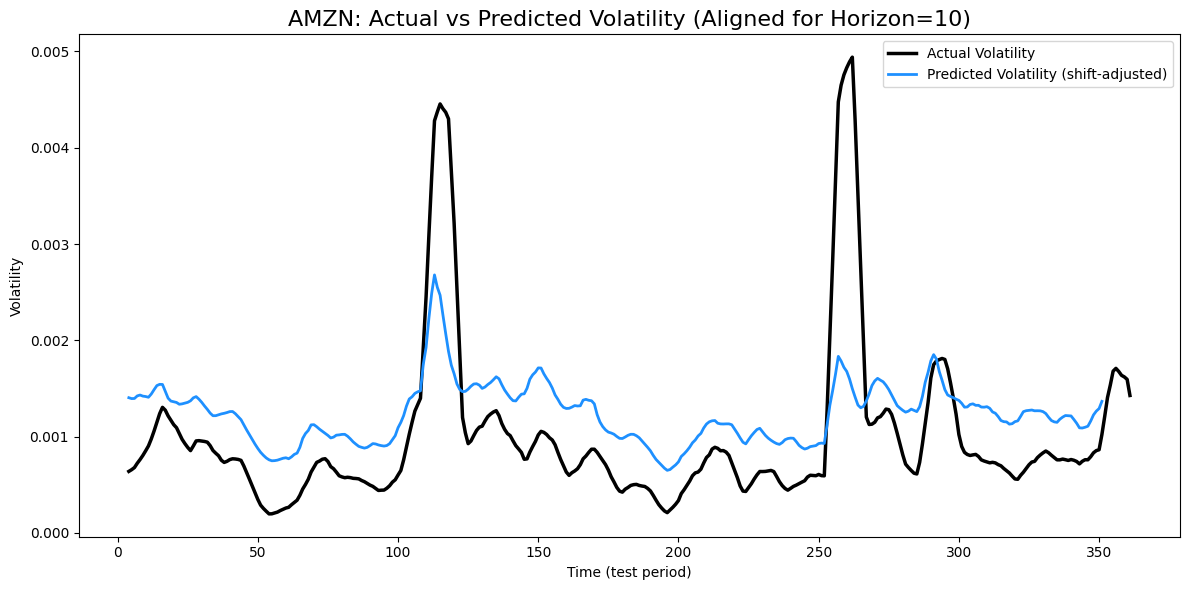

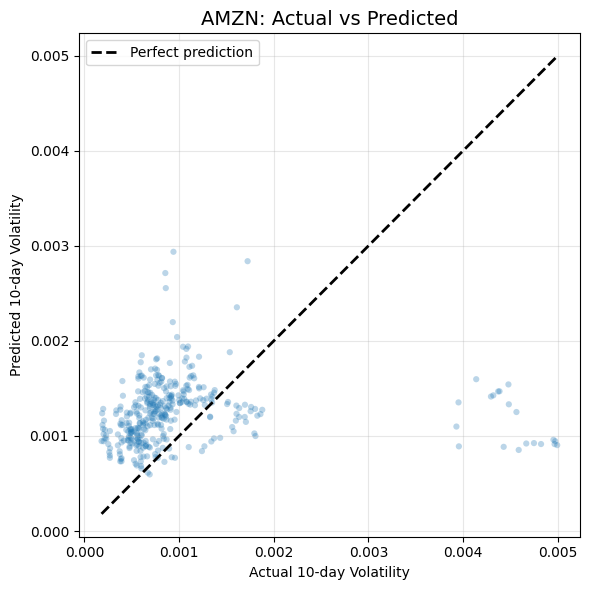

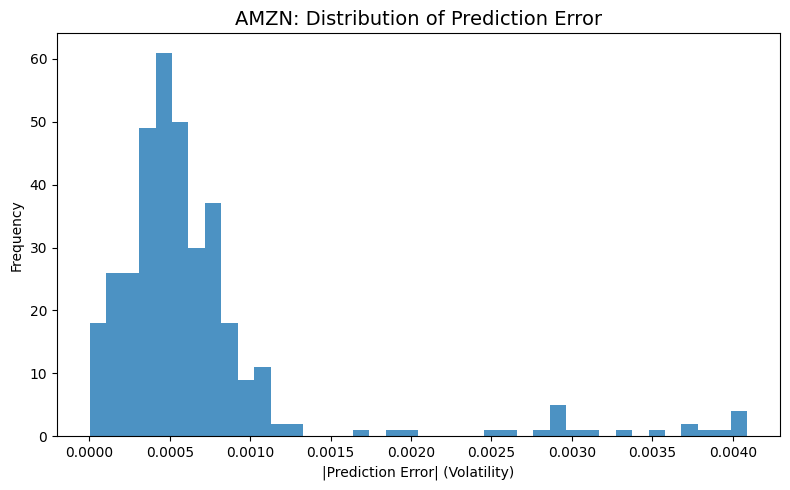

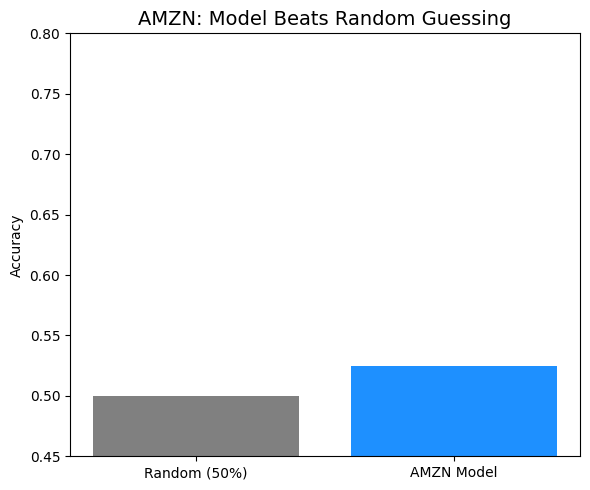


ANALYZING: MSFT
  Test period rows: 401
  Date range: 2016-03-30 00:00:00 to 2017-10-27 00:00:00

Ridge Performance:
R²: -0.2168 | Corr: 0.0190 | Dir: 0.561 | Quintile: 0.696
LSTM Performance:
R²: -0.0486 | Corr: 0.0895 | Dir: 0.602 | Quintile: 0.633

 Best model: LSTM (R² = -0.0486)
  Generating visualizations using LSTM predictions...



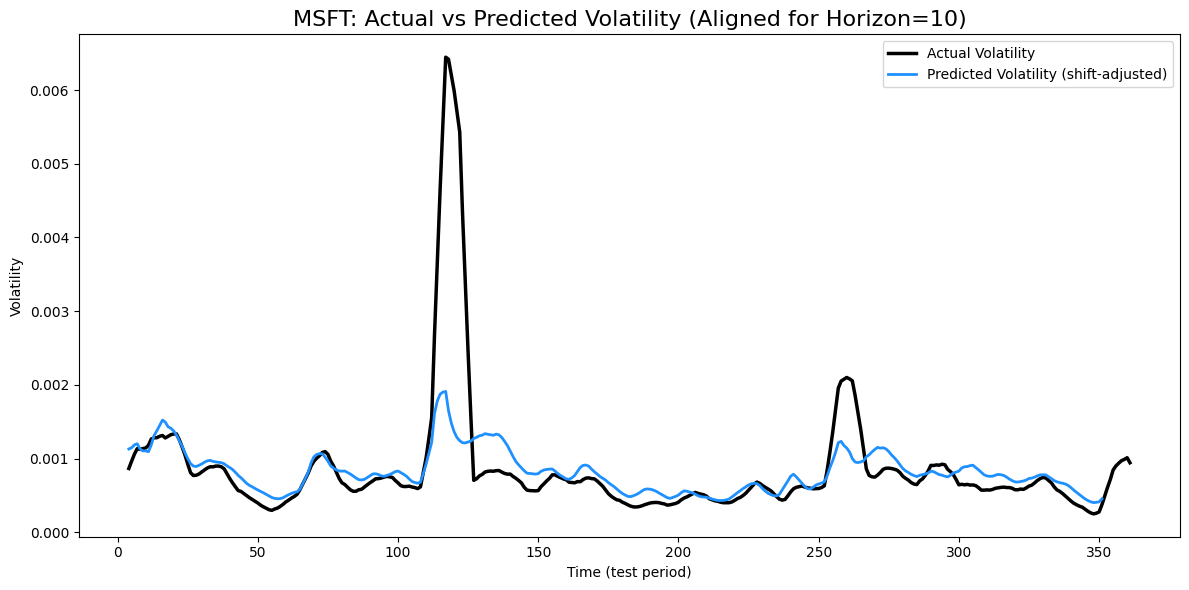

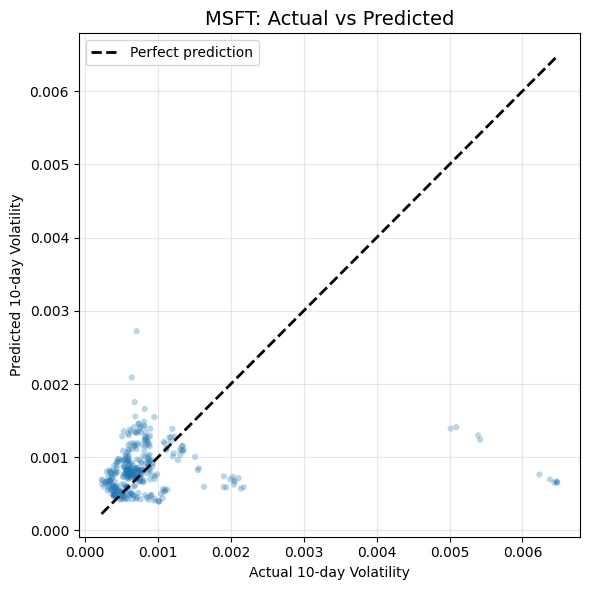

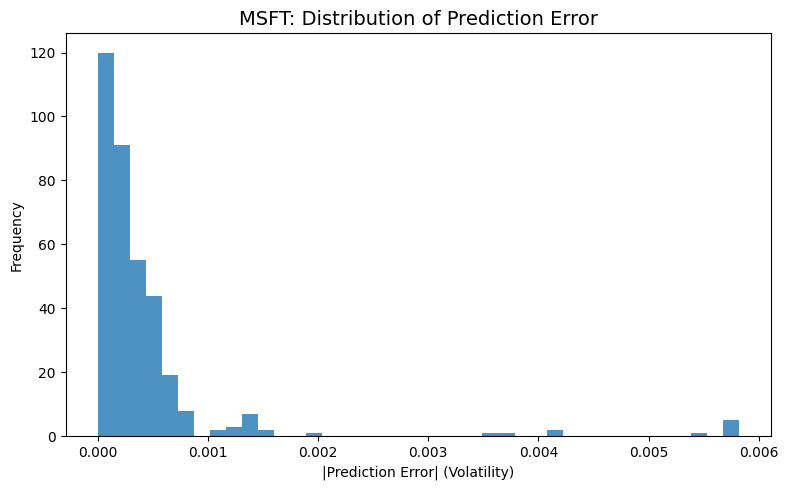

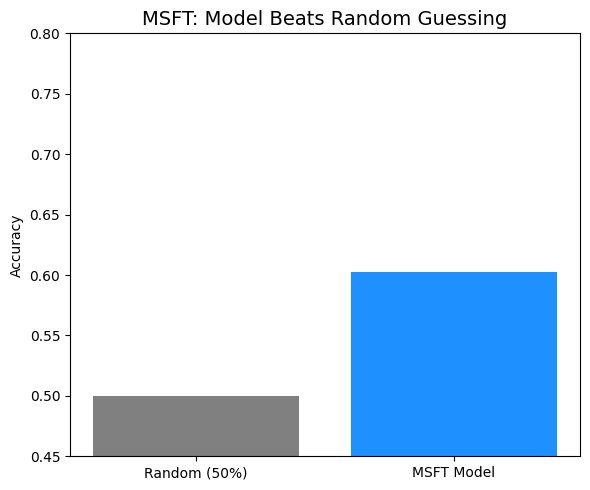


ANALYZING: TSCO
  Test period rows: 401
  Date range: 2016-03-30 00:00:00 to 2017-10-27 00:00:00

Ridge Performance:
R²: -0.0726 | Corr: 0.2694 | Dir: 0.544 | Quintile: 0.613
LSTM Performance:
R²: -0.0039 | Corr: 0.3325 | Dir: 0.602 | Quintile: 0.616

 Best model: LSTM (R² = -0.0039)
  Generating visualizations using LSTM predictions...



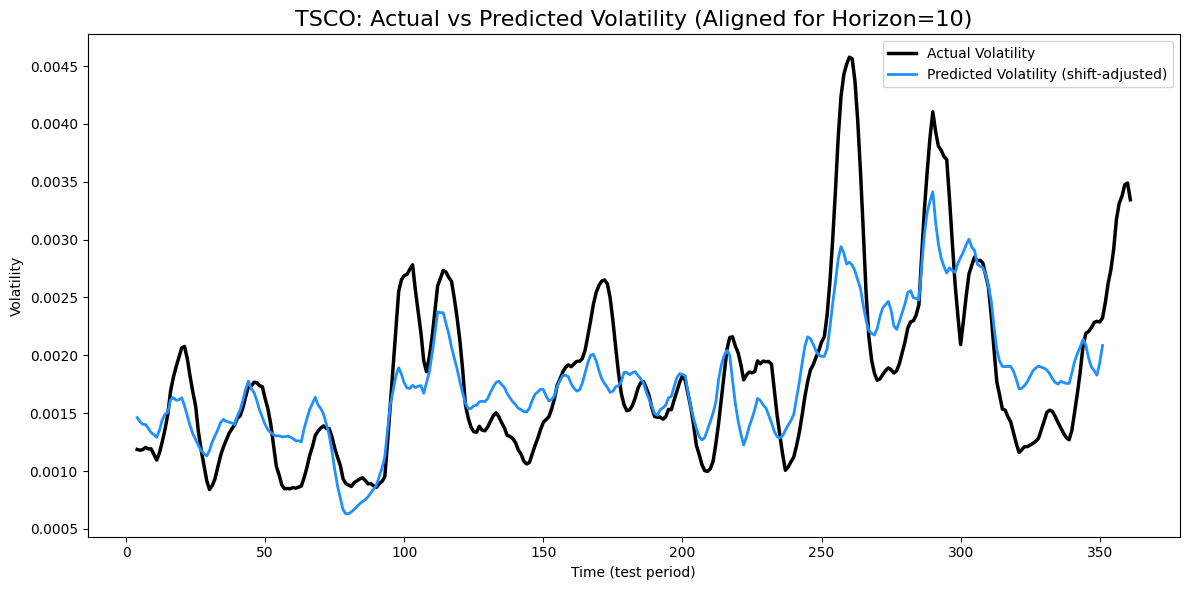

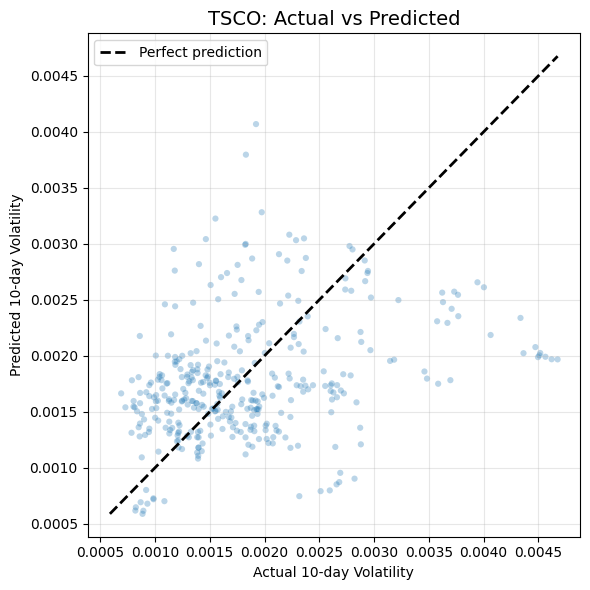

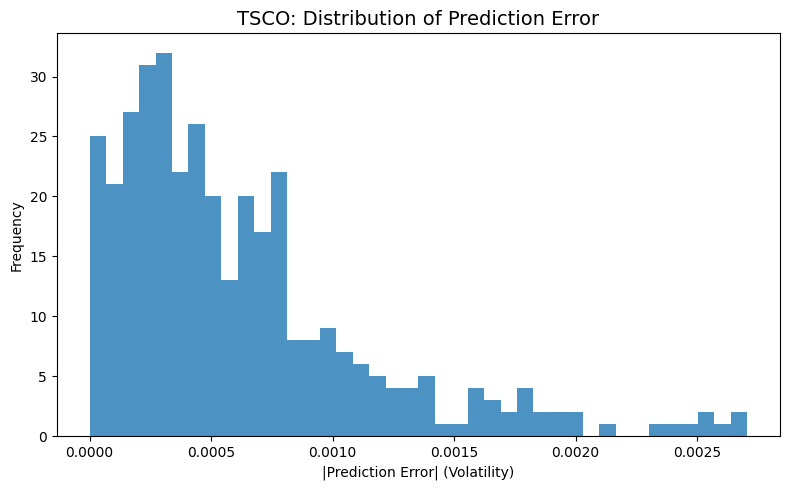

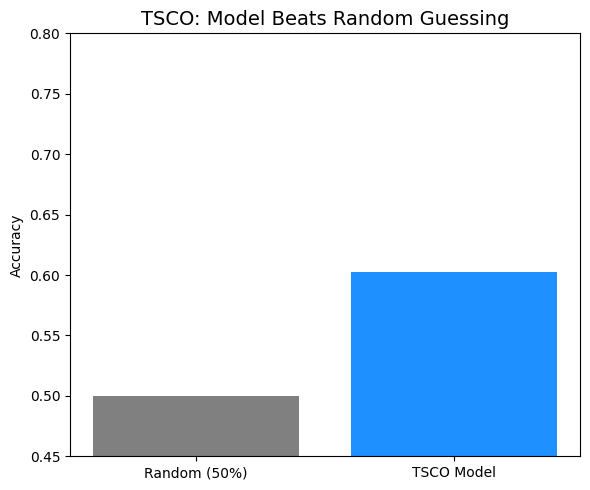

In [88]:
available_tickers = sorted(df_all["Ticker"].unique())

for tk in FOCUS_TICKERS:
    if tk not in available_tickers:
        print(f"\n[{tk.upper()}] Not found in dataset after processing, skipping.")
        continue

    print(f"\n{'='*80}")
    print(f"ANALYZING: {tk.upper()}")
    print(f"{'='*80}")

    df_tk_test = df_test[df_test["Ticker"] == tk].copy()

    if len(df_tk_test) < 50:
        print(f"Insufficient test data ({len(df_tk_test)} rows), skipping.")
        continue

    print(f"  Test period rows: {len(df_tk_test)}")
    print(f"  Date range: {df_tk_test['Date'].min()} to {df_tk_test['Date'].max()}")

    # Ridge performance for this ticker
    y_true_tk = df_tk_test["target_real"].values
    ridge_pred_tk = df_tk_test["ridge_pred_real"].values

    res_ridge_tk = compute_metrics(y_true_tk, ridge_pred_tk)

    print(f"\nRidge Performance:")
    print(f"R²: {res_ridge_tk['r2']:.4f} | Corr: {res_ridge_tk['corr']:.4f} | "
          f"Dir: {res_ridge_tk['dir_acc']:.3f} | Quintile: {res_ridge_tk['quintile_acc']:.3f}")

    # LSTM performance for this ticker (if available)
    res_lstm_tk = None
    lstm_pred_tk = None
    y_true_lstm_tk = None

    if meta_test is not None:
        meta_tk = meta_test[meta_test["Ticker"] == tk].copy()
        if len(meta_tk) >= 30:
            y_true_lstm_tk = meta_tk["target_real"].values
            lstm_pred_tk = meta_tk["lstm_pred_real"].values
            res_lstm_tk = compute_metrics(y_true_lstm_tk, lstm_pred_tk)

            print(f"LSTM Performance:")
            print(f"R²: {res_lstm_tk['r2']:.4f} | Corr: {res_lstm_tk['corr']:.4f} | "
                  f"Dir: {res_lstm_tk['dir_acc']:.3f} | Quintile: {res_lstm_tk['quintile_acc']:.3f}")
        else:
            print(f"LSTM: Insufficient sequence data ({len(meta_tk)} points)")

    # Choose best model for visualization
    candidates = {"Ridge": res_ridge_tk}
    preds = {"Ridge": ridge_pred_tk}
    y_refs = {"Ridge": y_true_tk}

    if res_lstm_tk is not None:
        candidates["LSTM"] = res_lstm_tk
        preds["LSTM"] = lstm_pred_tk
        y_refs["LSTM"] = y_true_lstm_tk

    best_name = max(candidates.keys(), key=lambda m: candidates[m]["r2"])
    best_res = candidates[best_name]
    best_pred = preds[best_name]
    best_y_true = y_refs[best_name]

    print(f"\n Best model: {best_name} (R² = {best_res['r2']:.4f})")
    print(f"  Generating visualizations using {best_name} predictions...\n")

    plot_volatility_prediction(best_y_true, best_pred, tk.upper(), horizon=VOLATILITY_HORIZON)
    plot_actual_vs_pred_scatter(best_y_true, best_pred, tk.upper())
    plot_abs_error_hist(best_y_true, best_pred, tk.upper())
    plot_direction_accuracy(best_res["dir_acc"], tk.upper())


In [89]:
def avg(d, key):
    """Calculate average of a metric across all stocks."""
    vals = [v[key] for v in d.values() if key in v and not np.isnan(v[key])]
    return np.mean(vals) if vals else float('nan')

print("\nOverall Performance (averaged across all stocks):\n")

for model in ['Ridge', 'LSTM']:
    r = results[model]
    if r:
        print(f"{model:6s} Model:")
        print(f"  R² Score:           {avg(r,'r2'):.4f}")
        print(f"  Correlation:        {avg(r,'corr'):.4f}")
        print(f"  Direction Accuracy: {avg(r,'dir_acc'):.3f}  ({avg(r,'dir_acc')*100:.1f}%)")
        print(f"  Quintile Accuracy:  {avg(r,'quintile_acc'):.3f}  ({avg(r,'quintile_acc')*100:.1f}%)")
        print(f"  RMSE:               {avg(r,'rmse'):.6f}")
        print()


Overall Performance (averaged across all stocks):

Ridge  Model:
  R² Score:           0.1762
  Correlation:        0.4827
  Direction Accuracy: 0.871  (87.1%)
  Quintile Accuracy:  0.967  (96.7%)
  RMSE:               0.041299

LSTM   Model:
  R² Score:           0.1761
  Correlation:        0.5230
  Direction Accuracy: 0.874  (87.4%)
  Quintile Accuracy:  0.971  (97.1%)
  RMSE:               0.043114

